## Factor analysis of a Stock return

In [1]:
import script1

In [2]:
fa = script1.FactorAnalysis(r"stock_returns.xlsx",r"F-F_Research_Data_Factors_New.csv")

In [3]:
fa.prepare_data()

stock_returns dataframe
             Returns
Date                
1988-01-04  0.067797
1988-01-05 -0.023810
1988-01-06 -0.014634
1988-01-07  0.014851
1988-01-08 -0.008130
fama_french dataframe
            Mkt-RF   SMB   HML     RF
Date                                 
1926-07-01    0.10 -0.25 -0.27  0.009
1926-07-02    0.45 -0.33 -0.06  0.009
1926-07-06    0.17  0.30 -0.39  0.009
1926-07-07    0.09 -0.58  0.02  0.009
1926-07-08    0.21 -0.38  0.19  0.009
merged both dataframes


In [4]:
fa.fit_model()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     782.2
Date:                Mon, 31 Mar 2025   Prob (F-statistic):               0.00
Time:                        05:05:56   Log-Likelihood:                 24515.
No. Observations:                8875   AIC:                        -4.902e+04
Df Residuals:                    8871   BIC:                        -4.899e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0106      0.000    -65.057      0.0

{'p_values': <Figure size 1000x600 with 1 Axes>,
 'params': <Figure size 1000x600 with 1 Axes>}

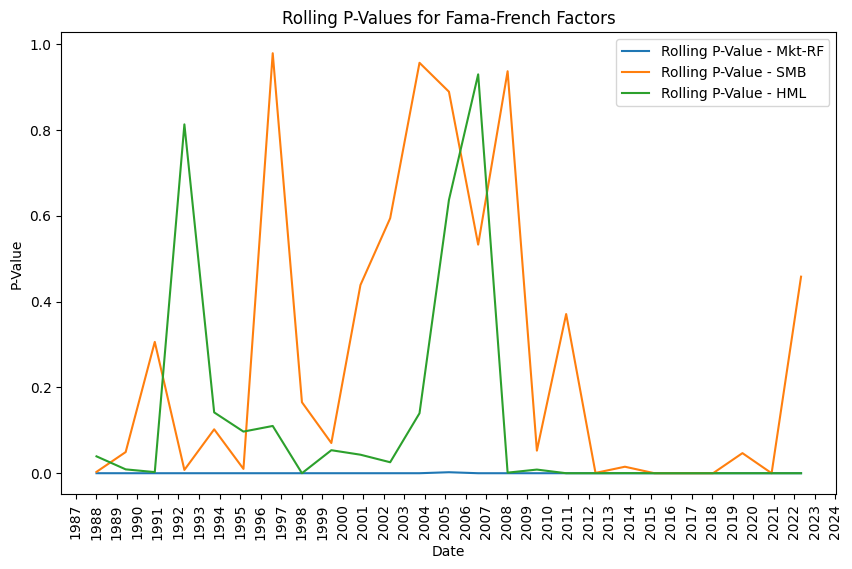

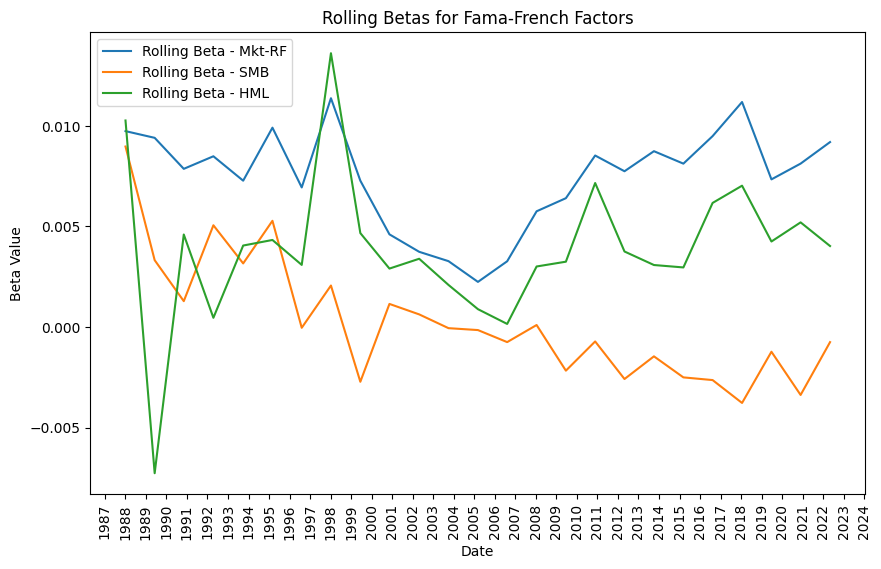

In [5]:
fa.fit_rolling_model('Rough',360)

The window_size 360 suggests 360 days

{'p_values': <Figure size 1000x600 with 1 Axes>,
 'params': <Figure size 1000x600 with 1 Axes>}

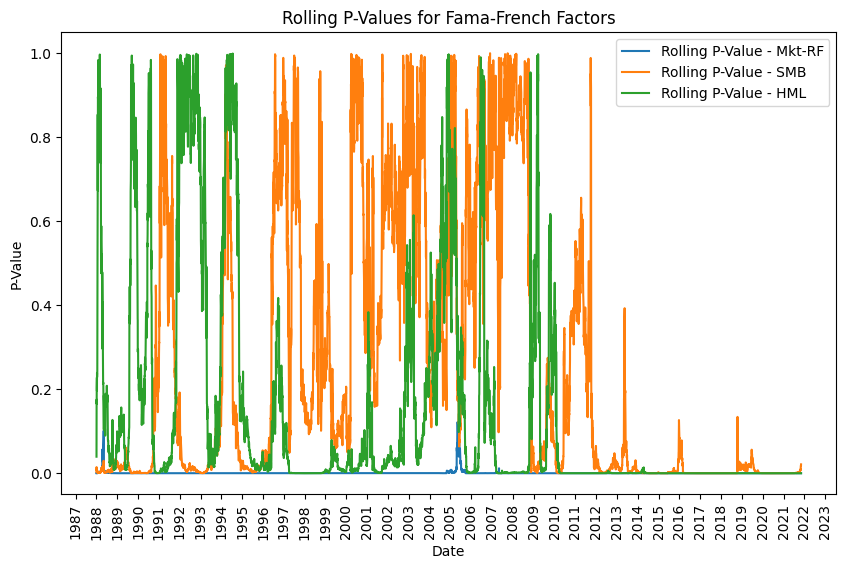

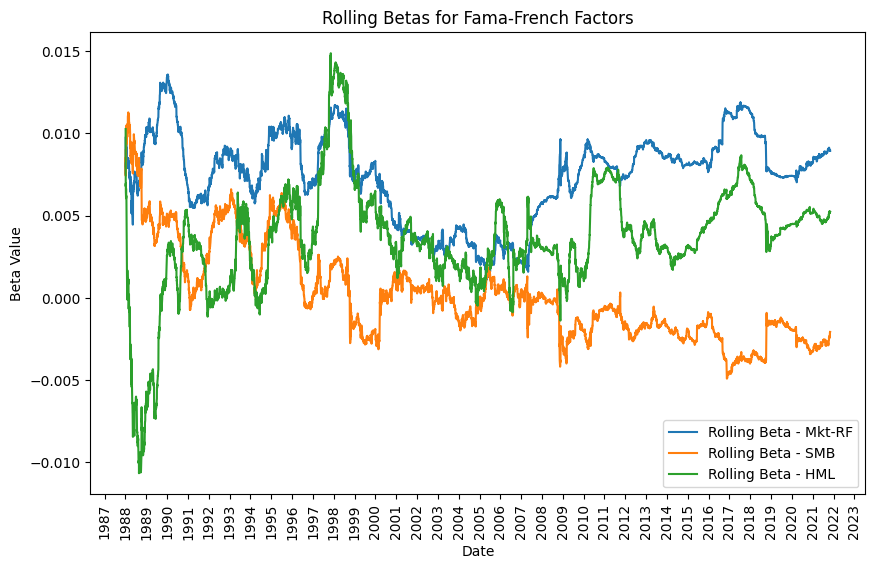

In [6]:
fa.fit_rolling_model('Smooth',window_size = 360)

## Fama-French Factor Model Analysis

### OLS Analysis Summary
- The **Fama-French factors explain 20.9%** of the variance in excess stock returns.  
- The **F-statistic indicates the model is significant**, meaning at least one of the coefficients of the factors in the model is non-zero.  

---

### Coefficient Interpretation
- The coefficients of **HML** and **excess market return** are **positive and significant**, suggesting that:  
  - The stock tends to behave like a **value stock**.  
  - The stock's returns are correlated with the **overall market**.  

- The **SMB factor coefficient** is **close to zero** and **not significant at the 5% level**.  
  - This could be due to the **SMB factor weights** in the rolling regression plot transitioning from **positive to negative in recent years**, causing the coefficient to average out to zero when using the complete dataset.  

---

### Trend Analysis
- There is a trend where the stock becomes more **value-oriented** and exhibits **large-cap stock behavior** over time i.e., from past to present.  
  - This trend is based on the **HML and SMB coefficient patterns** observed.  

- Analyzing data from **rolling time periods** reveals that:  
  - The **significance values of SMB and HML** factors exhibit an **inverse relationship until 2008**, after which both become **significant in recent years**.  
  - The **excess market return factor** remains **significant** throughout and has a **higher coefficient** most of the time.  


## Tracking Error Minimization

In [7]:
tem = script1.TrackingErrorMinimization(r'10_Industry_Portfolios.csv',r'port_returns.csv')

In [8]:
tem.prepare_data()

Industry_returns data frame
             NoDur   Durbl   Manuf   Enrgy   HiTec   Telcm   Shops   Hlth   \
Date                                                                         
1926-07-01  0.0145  0.1555  0.0469 -0.0118  0.0290  0.0083  0.0011  0.0177   
1926-08-01  0.0397  0.0368  0.0281  0.0347  0.0266  0.0217 -0.0071  0.0425   
1926-09-01  0.0114  0.0480  0.0115 -0.0339 -0.0038  0.0241  0.0021  0.0069   
1926-10-01 -0.0124 -0.0823 -0.0363 -0.0078 -0.0458 -0.0011 -0.0229 -0.0057   
1926-11-01  0.0520 -0.0019  0.0410  0.0001  0.0471  0.0163  0.0643  0.0542   

             Utils   Other  
Date                        
1926-07-01  0.0704  0.0213  
1926-08-01 -0.0169  0.0435  
1926-09-01  0.0204  0.0029  
1926-10-01 -0.0263 -0.0284  
1926-11-01  0.0371  0.0211  
Portfolio_returns data frame
            Portfolio returns
Date                         
1926-07-01           0.010643
1926-08-01           0.029051
1926-09-01          -0.004286
1926-10-01          -0.037112
1926-11-01   

#### Recovering and plotting the weights

Restricted license - for non-production use only - expires 2026-11-23


{'bar_graph': <Figure size 1000x600 with 1 Axes>}

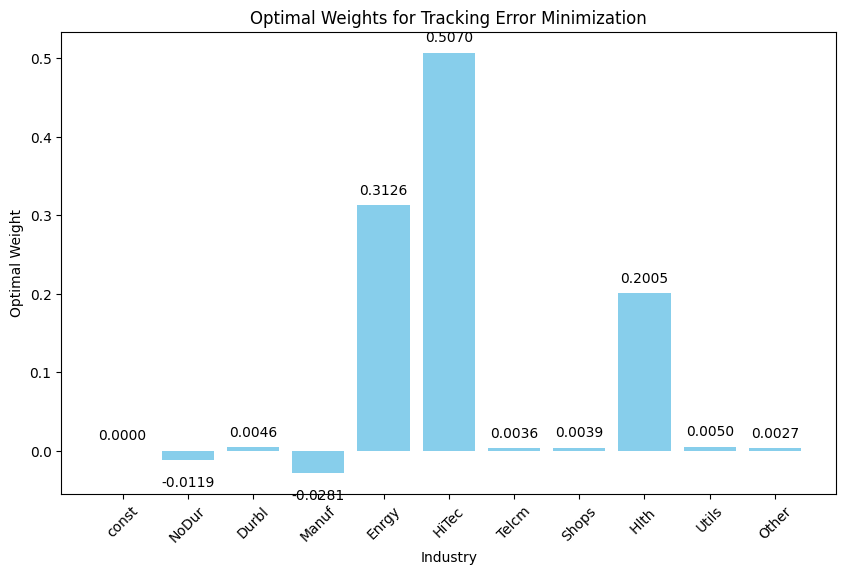

In [9]:
tem.opt_weights_bargraph()

#### Rolling analysis of weights

Here the rolling window = 90 means 90 month rolling window

{'rolling_weights': <Figure size 1200x800 with 1 Axes>}

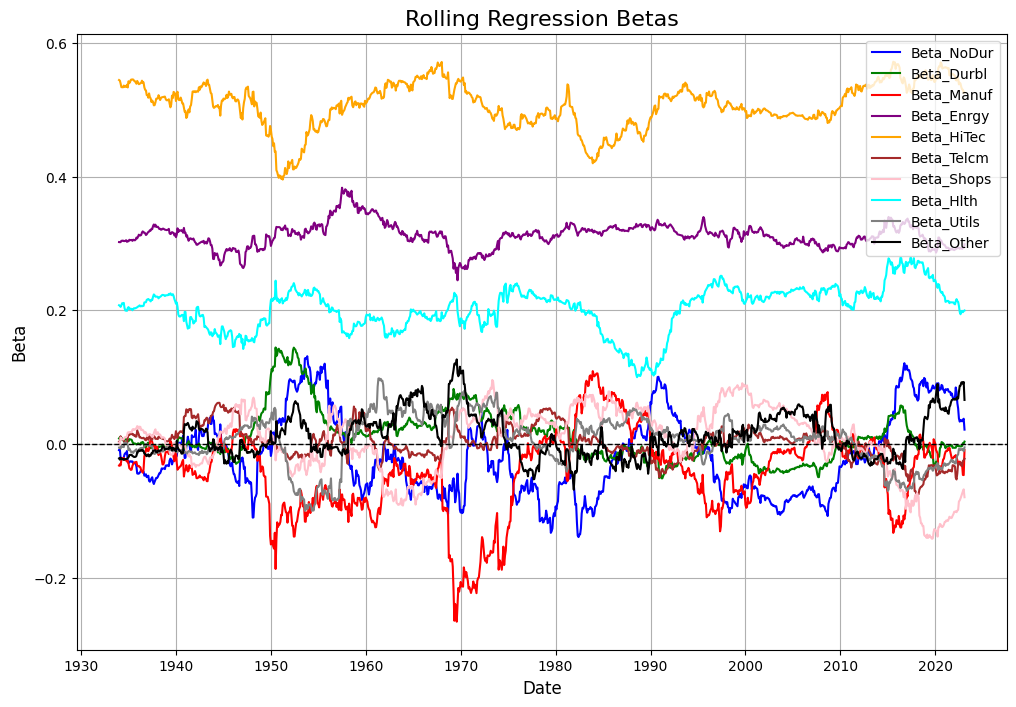

In [10]:
tem.opt_weights_rolling(90)

## Tracking Error Minimization Analysis

When we minimize the tracking error for a **rolling window of 90 months** and plot the weights obtained for different industry sectors, we observe the following:

- The **highest weightage** is consistently given to the **HiTec**, **Energy**, and **Health** industries.  
- Over time, the **Durbl** and **Manuf** industries appear to be **inversely related** to each other, similar to the relationship between **Others** and **Shops**.  


## Currency Model

## Error Correction Model for Exchange Rate Prediction

The model used here is the **Error Correction Model (ECM)**, which is employed to incorporate **long-term equilibrium effects** into the **short-term dynamics** of a dependent variable.

### Challenges in Exchange Rate Prediction

It is well known that **exchange rate fluctuations** are difficult to predict using economic models. In fact, **random walk models** often forecast exchange rates more accurately than any economic model — a phenomenon known as the **Meese and Rogoff puzzle**.

### Insights from Literature

According to a Rossi, Barbara. "Exchange rate predictability." Journal of economic literature 51.4 (2013): 1063-1119, certain economic fundamentals have demonstrated **better out-of-sample predictive power** for exchange rates:

- **GDP along with interest rates** have shown good predictive performance.
- **Difference between inflation rate and target inflation rate**, as well as the **difference between nominal interest rate and inflation rate** (referred to as **Taylor’s rule fundamentals**), also exhibit promising results.
- **Net foreign asset positions** have shown potential for improving exchange rate forecasts.

### Successful Models

Among the models explored, the **panel ECM models** have been the most successful. However, the **choice of predictors** plays a more crucial role in model success than the model type itself.


### Model Selection
Error Correction Models are used when there are **cointegration relationships** between the factors being used. This is ascenrtained by Johansen's cointegration test. These models incorporate **error correction terms**, which represent deviations from long-term equilibrium, into the **short-term behavior** of variables.

### Model Structure

In ECM, we model **differenced variables** along with an additional error term, as shown below:

$$
\Delta X_t = \beta_0 + \beta_1 \Delta M_t + \beta_2 \epsilon_{t-1} + \nu_t
$$

Where:
- $\Delta X_t$ = Differenced Dependent variable  
- $\Delta M_t$ = Differenced Independent variables  
- $\epsilon_{t-1}$ = Error correction term (from the previous period)  
- $\nu_t$ = Error term  

#### Estimating the Error Term

To obtain the error term, we perform a **simple OLS regression** to estimate the dependent variable. The **residuals from this model** as shown below serve as the error correction term.

$$
\epsilon_t = X_t - \beta_0 - \beta_1 M_t
$$

This approach is known as **Engle-Granger cointegration analysis**, which is used when there are **two variables and one cointegrating relationship**. 

#### Interpretation of $\beta_2$ from ECM equation

$\beta_2$ is the **error correction term's estimated coefficient**, where:

$-1 < \beta_2 < 0$

This coefficient indicates the **speed of adjustment** towards the **long-run equilibrium**.

---

### Vector Error Correction Model (VECM)

When dealing with **multiple time series**, we use the **Vector Error Correction Model (VECM)**. In this case, we estimate a **VAR model on differenced variables** while incorporating the error correction terms and cointegrating equations to account for:

- Adjustments towards long-run equilibrium  
- Long-run cointegrating relationships  

#### VECM Equation

$$
\Delta y_t = \nu + \Pi Y_{t-1} + \theta_1 \Delta y_{t-1} + \theta_2 \Delta y_{t-2} + \dots + \theta_{p-1} \Delta y_{t-(p-1)} + \nu_t
$$

Where:
- $\nu$ = Vector of constants  
- $\theta_1$, $\theta_2$ = Short-run coefficients  
- $\Delta y_{t-(p-1)}$ = Lagged differences representing short-run impact where $p \in (2, \dots)$  
- $\nu_t$ = Vector of impulses  

This model structure effectively **captures both short-term dynamics and long-term equilibrium** relationships within the time series data.


## Transformations on the Variables

The following transformations are performed for modeling:

### 1. Differencing

The **exchange rate** and **Balance of Payments (BOP)** features are **differenced once**. This transformation helps achieve **stationarity**, making the series more suitable for modeling. Additionally, differencing aids in the **interpretation** of the model by eliminating trends and stabilizing the mean.

### 2. Lagging the Differenced Features

The **differenced features** are lagged up to different time periods because:

- As we aim to predict changes in the exchange rate using **past information**.  
- There is viable as often a **delay in the effect** of information on the market is seen.  
- Different changes may influence the exchange rate at varying delay periods.  

By including **lagged variables**, the model captures the **dynamic relationship** between past changes and future movements.

### 3. Lagging the Error Correction Term

The **Error Correction Term (ECT)** is also lagged. This is because the deviation observed in the current period is used to correct the future predicted values. This adjustment ensures that the model accounts for long-term equilibrium even when analyzing short-term dynamics.



In [11]:
import script1

In [12]:
cm = script1.CurrencyModel(r"DQ_DBIE_Excel_23_3_2025_3371.xlsx",r"DQ_DBIE_Excel_23_3_2025_7088.xlsx")

In [13]:
cm.prepare_data()

The data is created
<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1971 to 2024
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Year                                54 non-null     int64  
 1   year_end                            54 non-null     float64
 2   year_average                        54 non-null     float64
 3   Time Period / ACTUALS               54 non-null     int64  
 4   Current Account Deficit(CAD)/GDP    54 non-null     float64
 5   Current Receipts/ Current Payments  54 non-null     float64
 6   Current Receipts/ GDP               54 non-null     float64
 7   Exports/ GDP                        54 non-null     float64
 8   Foreign Investment/ Exports         54 non-null     float64
 9   Foreign Investment/ GDP             54 non-null     float64
 10  Imports of Reserve                  54 non-null     float64
 11  Imports/ GDP               

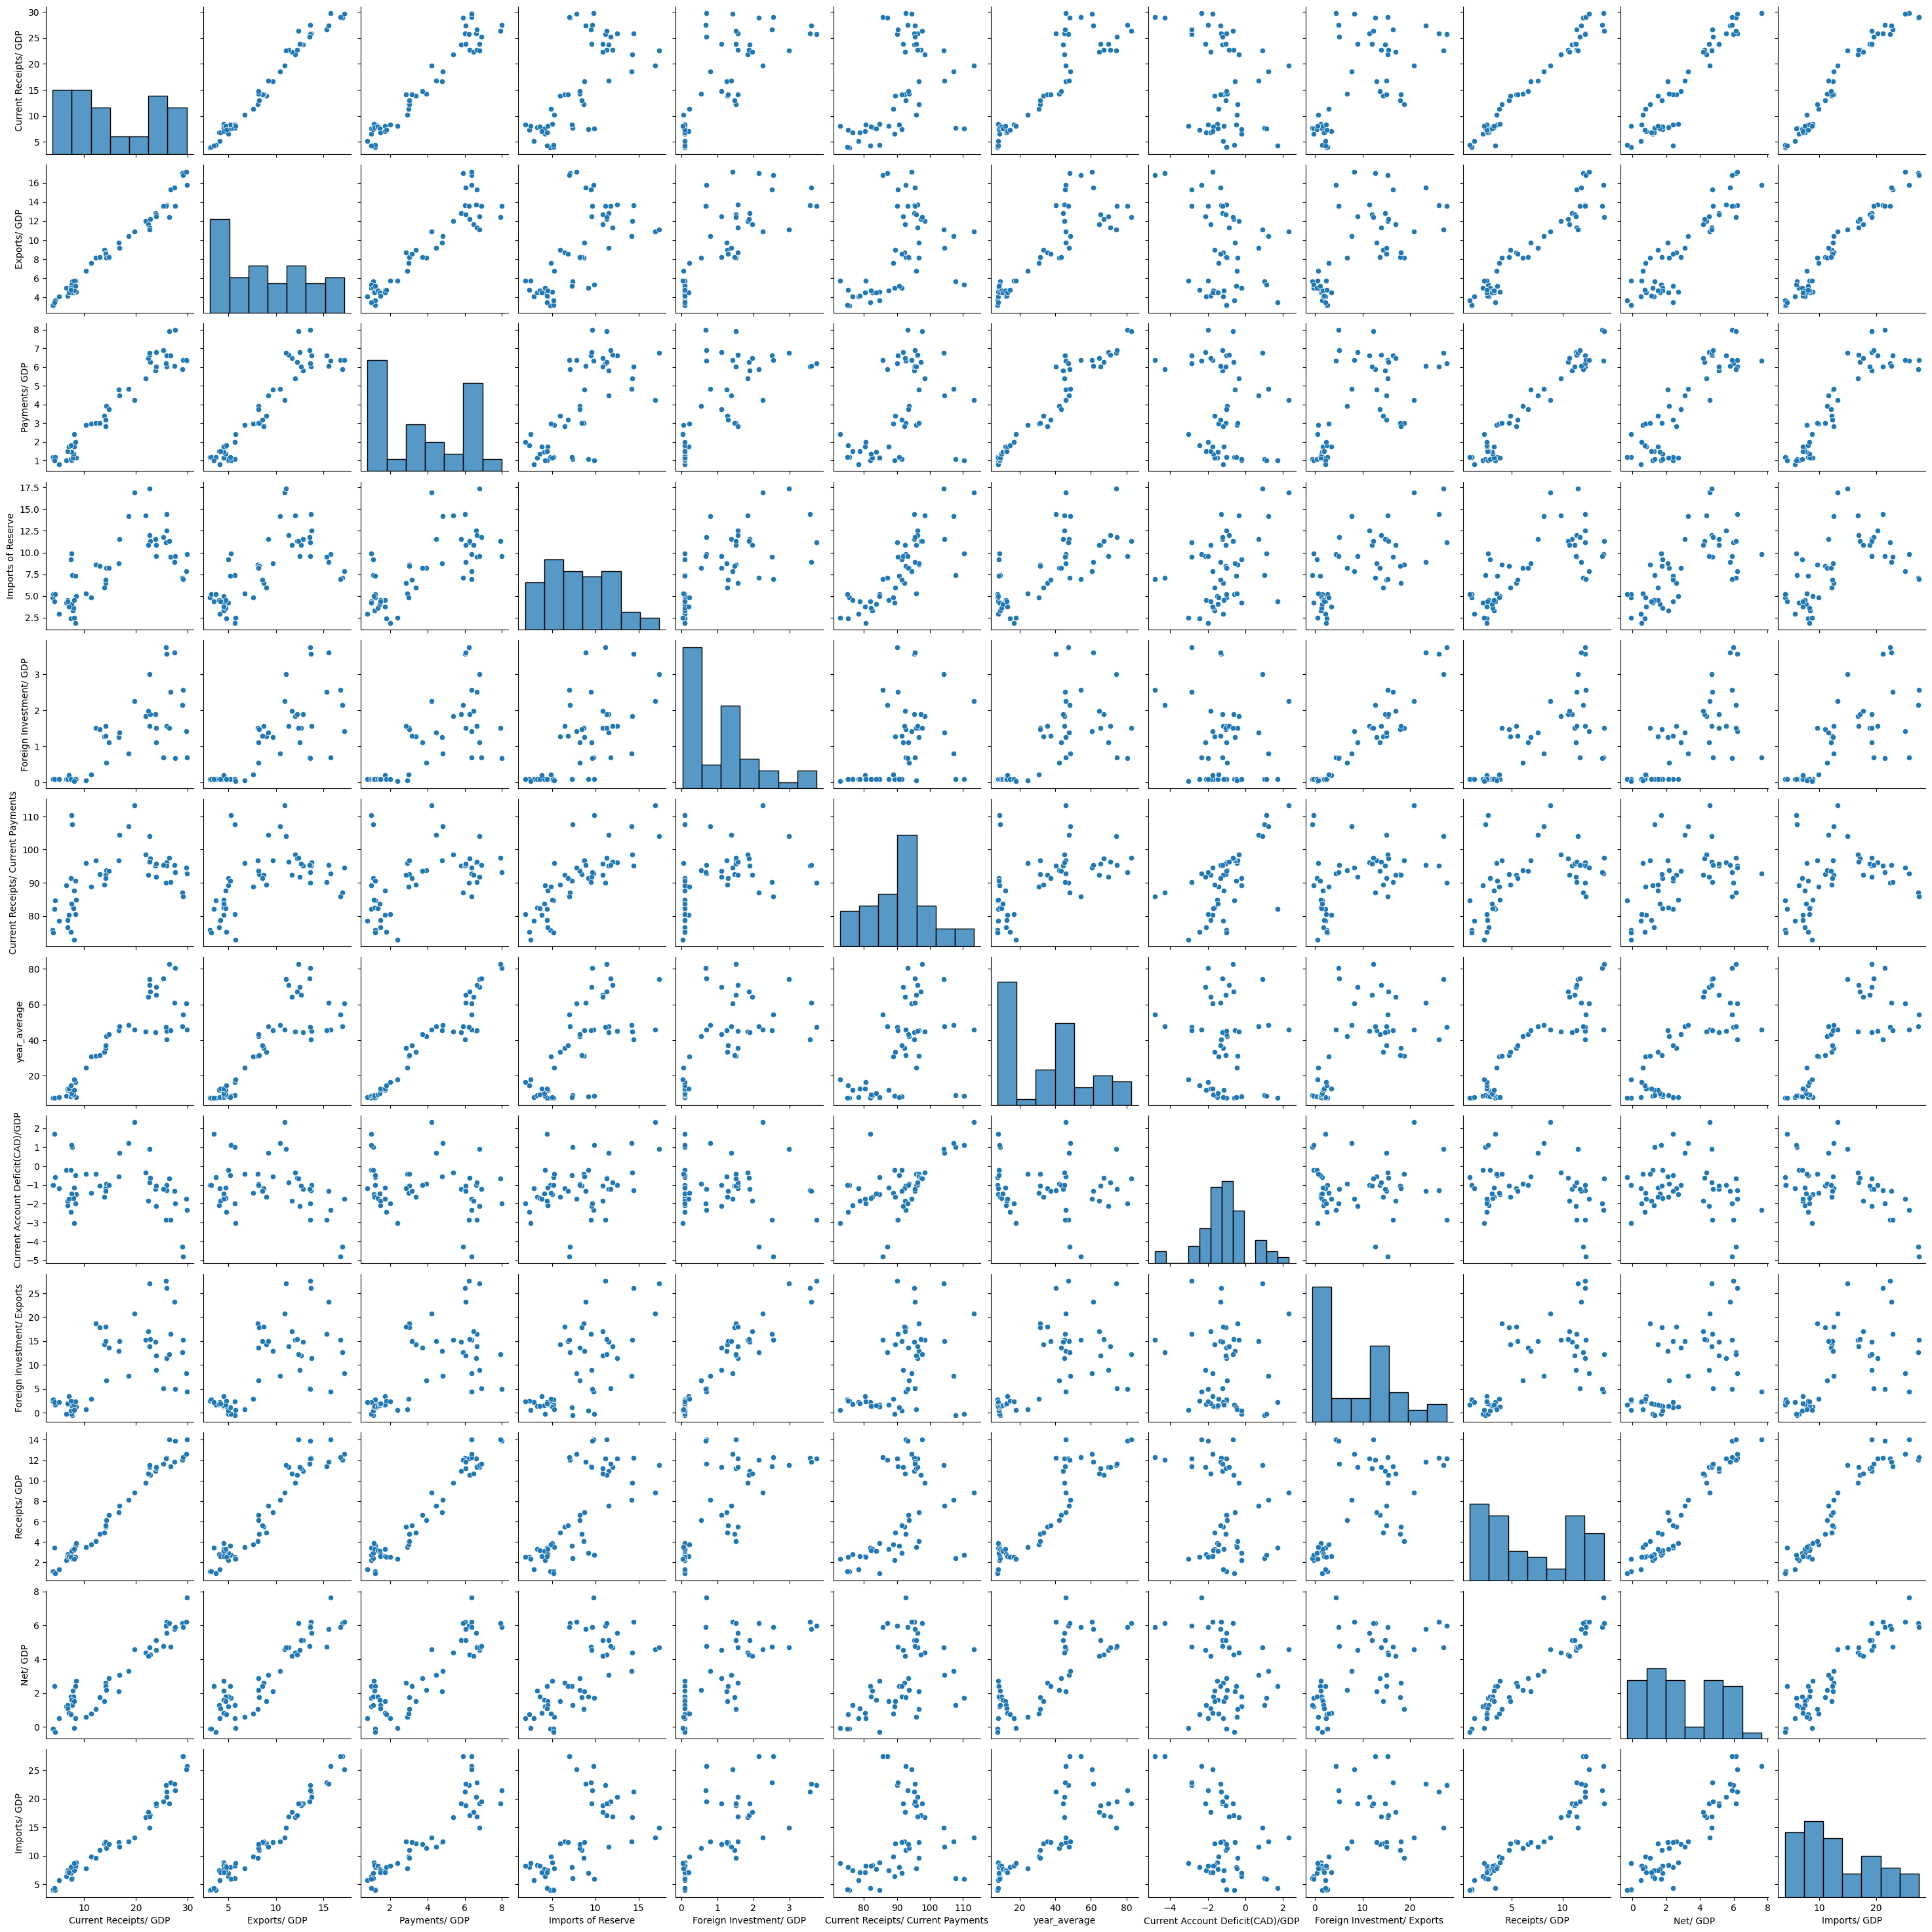

In [14]:
cm.pairplot()

We see that in the above graph, year_average (name given to currency exchange rate) is linear with other features except in the range of approx 50 to 70 where we see an upside down u shaped distortion.

In [15]:
cm.drop(['Year','year_end','Time Period / ACTUALS'])

Dropped columns ['Year', 'year_end', 'Time Period / ACTUALS']


In [16]:
cm.vif()

Variance Inflation Factor (VIF):
                               Feature           VIF
0     Current Account Deficit(CAD)/GDP  5.155836e+03
1   Current Receipts/ Current Payments  4.800225e+01
2                Current Receipts/ GDP  4.151282e+03
3                         Exports/ GDP  1.857573e+05
4          Foreign Investment/ Exports  4.379788e+01
5              Foreign Investment/ GDP  5.285507e+01
6                   Imports of Reserve  5.587215e+01
7                         Imports/ GDP  3.831272e+05
8                             Net/ GDP  2.083649e+11
9                        Payments/ GDP  3.084129e+11
10                       Receipts/ GDP  1.003699e+12


We observe very high variance inflation factors in the dataset thus we need to drop some variables.

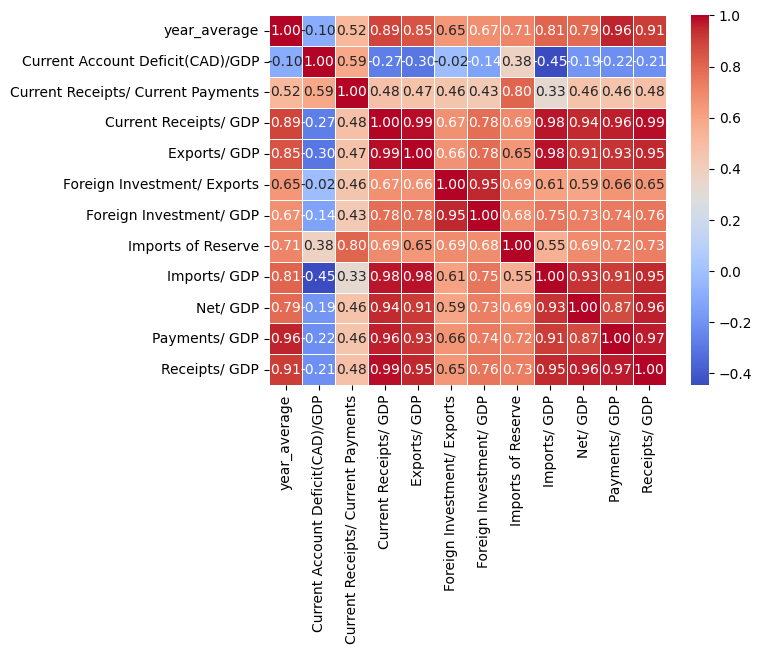

In [17]:
cm.heatmap()

We see that there is high correlation between different features thus dropping some features i.e., 'Receipts/ GDP','Imports/ GDP','Foreign Investment/ GDP','Exports/ GDP', 'Current Receipts/ GDP'

In [18]:
cm.drop(['Receipts/ GDP','Imports/ GDP','Foreign Investment/ GDP','Exports/ GDP', 'Current Receipts/ GDP'])

Dropped columns ['Receipts/ GDP', 'Imports/ GDP', 'Foreign Investment/ GDP', 'Exports/ GDP', 'Current Receipts/ GDP']


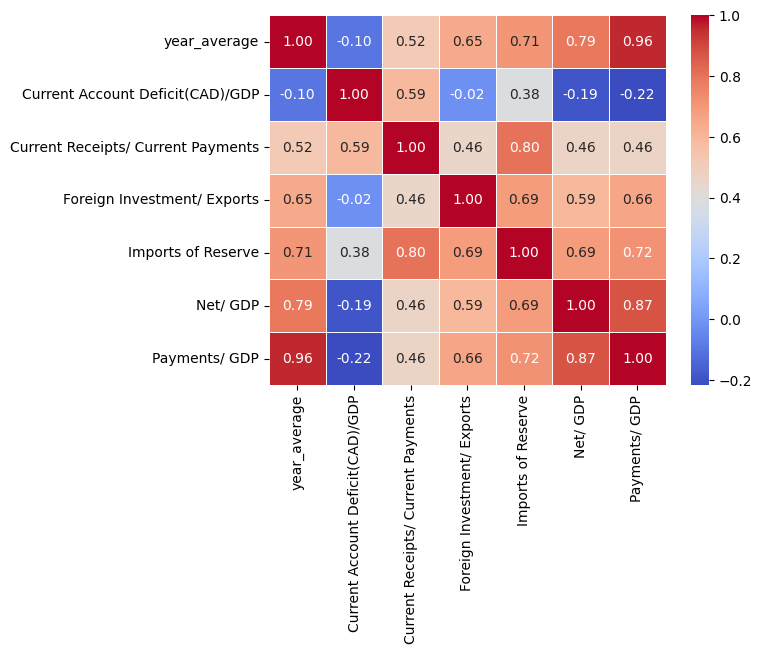

In [19]:
cm.heatmap()

To be able to apply VECM all the features in the data should be non stationary without differencing and become stationary when differenced for the first time. Thus checking for stationarity among variables using Augmented Dicky Fuller's test

In [20]:
cm.adfullertest()

@@@@@@@@@@@ Payments/ GDP
ADF Test on Level Data:
ADF Statistic: 0.5949
p-value: 0.9875
=> Series is non-stationary. Testing first difference...

ADF Test on First Difference:
ADF Statistic: -4.9563
p-value: 0.0000
=> First difference is stationary (series is I(1)).
@@@@@@@@@@@ Imports of Reserve
ADF Test on Level Data:
ADF Statistic: -2.0179
p-value: 0.2788
=> Series is non-stationary. Testing first difference...

ADF Test on First Difference:
ADF Statistic: -6.4192
p-value: 0.0000
=> First difference is stationary (series is I(1)).
@@@@@@@@@@@ Current Receipts/ Current Payments
ADF Test on Level Data:
ADF Statistic: -3.0832
p-value: 0.0278
=> Series is stationary (reject null hypothesis of unit root).
@@@@@@@@@@@ year_average
ADF Test on Level Data:
ADF Statistic: 1.5669
p-value: 0.9978
=> Series is non-stationary. Testing first difference...

ADF Test on First Difference:
ADF Statistic: -6.3635
p-value: 0.0000
=> First difference is stationary (series is I(1)).
@@@@@@@@@@@ Current A

We see that all the features are stationary at max by there first differencing

We draw the trend of features from the data to see if any trend exists to conduct Johansen's cointegration test

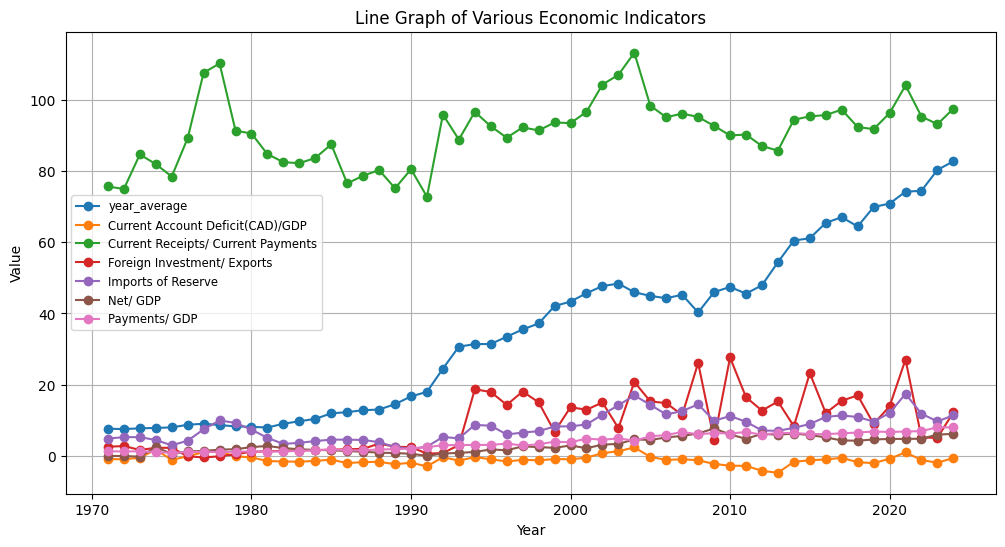

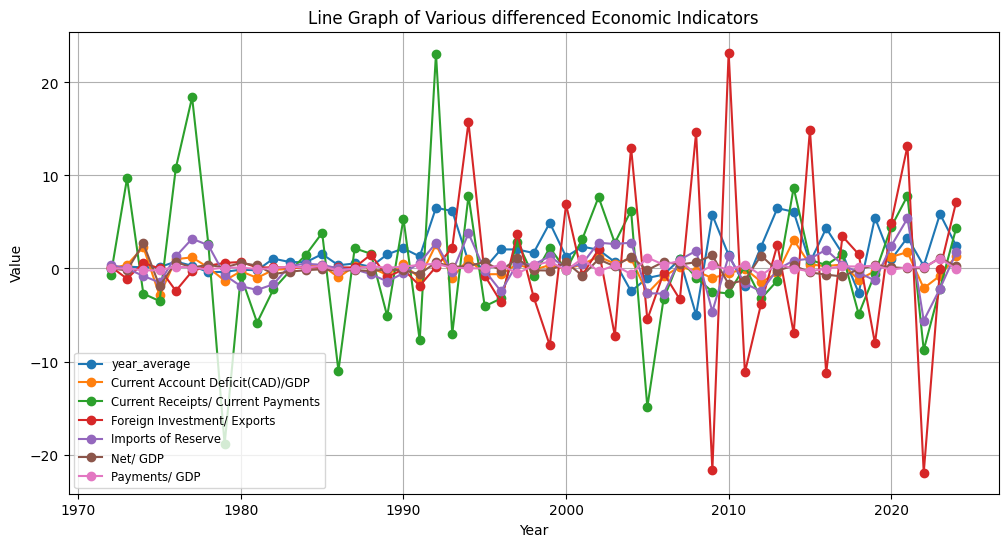

In [21]:
cm.graph_trend()

We see that in the first graph except for exchange rate i.e., year_average we dont see any trend thus we go with det_order=0 for cointegration test and lag =1, which we get from the test done below based on BIC criterion

In [22]:
cm.lagcheck()

Optimal lags based on:
AIC: 5
BIC: 1
HQIC: 5


F:\SSGA\ff\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [23]:
cm.cointtest()

Eigenvalues:
 [0.61952997 0.6131432  0.43436498 0.2847455  0.25033641 0.13743628
 0.00590525]

Trace Statistics:
 [169.66931193 119.41922337  70.0347874   40.40486205  22.97878577
   7.99598837   0.30798325]

Critical Values for Trace Statistics:
 [[120.3673 125.6185 135.9825]
 [ 91.109   95.7542 104.9637]
 [ 65.8202  69.8189  77.8202]
 [ 44.4929  47.8545  54.6815]
 [ 27.0669  29.7961  35.4628]
 [ 13.4294  15.4943  19.9349]
 [  2.7055   3.8415   6.6349]]

Max-Eigen Statistics:
 [50.25008855 49.38443597 29.62992535 17.42607628 14.9827974   7.68800512
  0.30798325]

Critical Values for Max-Eigen:
 [[43.2947 46.2299 52.3069]
 [37.2786 40.0763 45.8662]
 [31.2379 33.8777 39.3693]
 [25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


As we see the 4th max_eigen statistics and trace statistics are both much smaller than the 99 percentile values in the fourth row of critical values matrices thus rejecting the null hypothesis that there are more than three cointegration relationships in the data.

In [24]:
datamodeldict = cm.fitvecm()

k_ar_diff is taken as 1 and no of cointegratino relationships are 3


F:\SSGA\ff\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


### Plotting fitted values vs the actual values we get

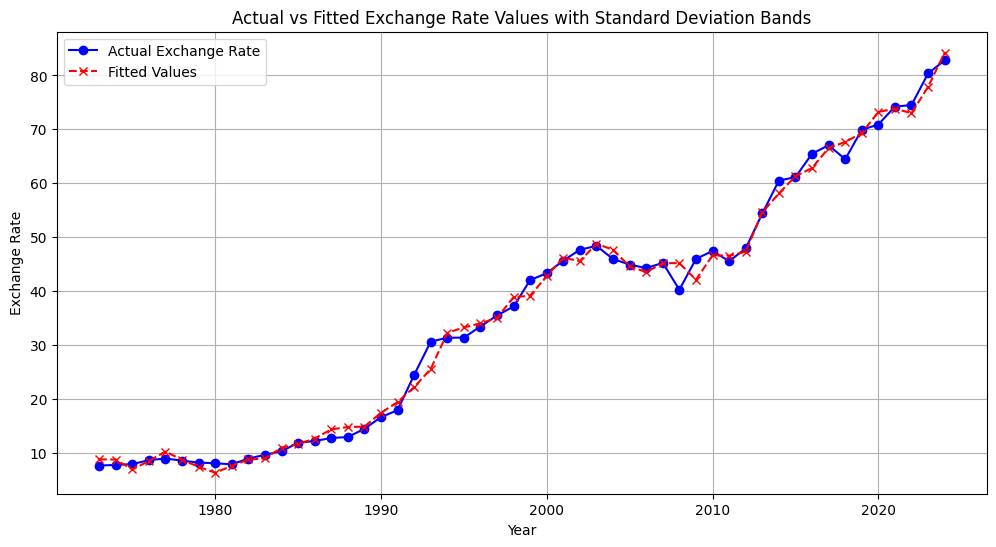

In [25]:
cm.fit_vs_actual(datamodeldict['model'])

### Testing the model

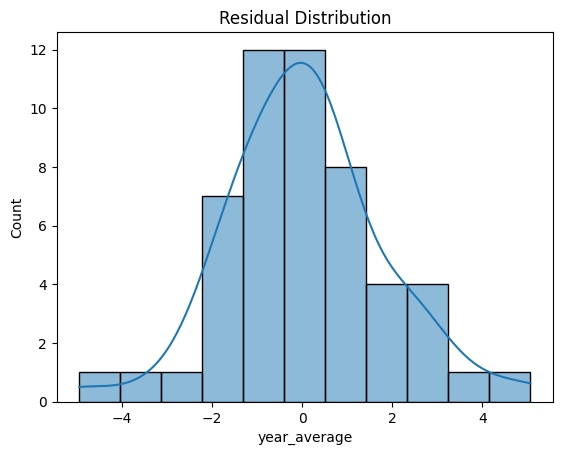

Shapiro-Wilk Test p-value: 0.31033931191340236


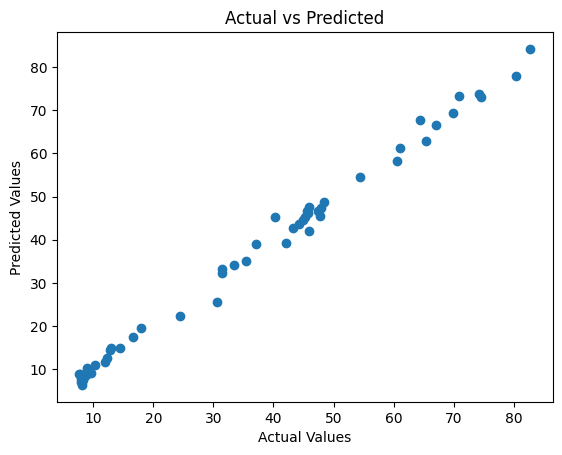

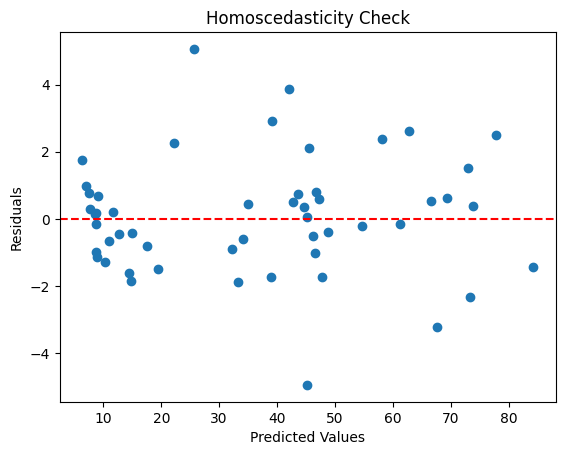

Serial Correlation Test:
 <statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: fail to reject at 5% significance level. Test statistic: 363.046, critical value: 468.782>, p-value: 0.979>
Normality Test:
 <statsmodels.tsa.vector_ar.hypothesis_test_results.NormalityTestResults object. H_0: data generated by normally-distributed process: reject at 5% significance level. Test statistic: 28.901, critical value: 23.685>, p-value: 0.011>
Heteroskedasticity Test:
 <statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: fail to reject at 5% significance level. Test statistic: 363.046, critical value: 468.782>, p-value: 0.979>


In [26]:
cm.vecm_tests(datamodeldict['model'])

We see that model passes the tests of Serial correlation, Heterokedasticity and residuals being approsimately Normal

### Model Interpretation

In [27]:
datamodeldict['model'].summary()

,coef,std err,z,P>|z|,[0.025,0.975]
L1.Current Account Deficit(CAD)/GDP,-0.4517,0.247,-1.827,0.068,-0.936,0.033
L1.Net/ GDP,-0.0866,0.210,-0.412,0.680,-0.498,0.325
L1.Imports of Reserve,0.3301,0.143,2.302,0.021,0.049,0.611
L1.Current Receipts/ Current Payments,0.0206,0.032,0.652,0.515,-0.041,0.082
L1.Payments/ GDP,0.5960,0.445,1.338,0.181,-0.277,1.469
L1.year_average,0.0075,0.081,0.093,0.926,-0.150,0.165
L1.Foreign Investment/ Exports,-0.0260,0.022,-1.162,0.245,-0.070,0.018
,coef,std err,z,P>|z|,[0.025,0.975]
L1.Current Account Deficit(CAD)/GDP,-0.1541,0.147,-1.045,0.296,-0.443,0.135
L1.Net/ GDP,-0.1241,0.125,-0.990,0.322,-0.370,0.121


->In the above summary if we see the equations related to year_average (i.e., only exchange_rate) we see L1.Net/GDP has significant positive impact on it.\
\
->Coefficients showing rate of change of correction related to year_average ec1 and ec2 are significant. Betas here are given for 3 cointegration relationships and represent long term impact of year_average on other features.\
\
->The EC Coefficients and Betas of other features all have impact on year_features and the multiplication of matrices alpha and beta give us the cointegration matrix $\pi$.

### Prediction upto two periods

In [28]:
y_pred = datamodeldict['model'].predict(steps=2)

In [29]:
y_predicted = [float(y_pred[i][5]) for i in range(0,y_pred.shape[0])]
y_predicted

[85.33374427459415, 88.02179677693411]

The above are the predicted values for currency exchange for 2025 and 2026

In the above summary if we see the equatinos related to year_average (i.e., only exchange_rate) we see L1.Net/GDP has significant positive impact on it.\
\
Coefficients showing rate of change of correction related to year_average ec1 and ec2 are significant. Betas here are given for 3 cointegration relationships and represent long term impact of year_average on other features.\
\
The EC Coefficients and Betas of other features all have impact on year_features and the multiplication of matrices alpha and beta give us the cointegration matrix $\pi$

### ECM Model

#### On implementing Engel Grenger method below assuming there exists only single cointegration equation to find error correction term and taking multiple lags on differences of dependent features and regressing difference of currency exchange on the differences of features along with ect. We see that we get a model which does not pass the residual tests and gives biased results.

In [30]:
ex_bop_data = datamodeldict['data'].copy()

#### Long term model to get residuals

In [31]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

In [32]:
# Step 2: Cointegration Test
for i in list(set(ex_bop_data.columns.to_list())-set(['year_average'])):
    coint_result = coint(ex_bop_data['year_average'], ex_bop_data[i])
    print(f'Cointegration Test Statistic for {i}: {coint_result[0]}')
    print(f'p-value for {i}: {coint_result[1]}')

Cointegration Test Statistic for Payments/ GDP: -2.4252151164560893
p-value for Payments/ GDP: 0.3130073779845957
Cointegration Test Statistic for Imports of Reserve: -1.7631174517842128
p-value for Imports of Reserve: 0.6474580736163607
Cointegration Test Statistic for Current Receipts/ Current Payments: -0.7352199862981683
p-value for Current Receipts/ Current Payments: 0.9427013017716546
Cointegration Test Statistic for Current Account Deficit(CAD)/GDP: -0.6690155995078543
p-value for Current Account Deficit(CAD)/GDP: 0.9498793301673899
Cointegration Test Statistic for Net/ GDP: -1.5382218306704003
p-value for Net/ GDP: 0.7462457829528576
Cointegration Test Statistic for Foreign Investment/ Exports: 0.18173042324663768
p-value for Foreign Investment/ Exports: 0.9893372978463281


In the above test we see cointegration relationship exists for all features.

In [33]:
X = sm.add_constant(ex_bop_data[list(set(ex_bop_data.columns.to_list()) - set(['year_average']))])

# Define the dependent variable (year_average)
y = ex_bop_data['year_average']

# Fit the OLS model
long_run_model = sm.OLS(y, X).fit()

# Store the residuals
ex_bop_data['Long_Run_Residual'] = long_run_model.resid

In [34]:
ex_bop_data1 = ex_bop_data.copy(deep=True)

In [35]:
ex_bop_data1[list(set(ex_bop_data1.columns.to_list())-set(['Long_Run_Residual']))] = ex_bop_data1[list(set(ex_bop_data.columns.to_list())-set(['Long_Run_Residual']))].diff()
ex_bop_data1.dropna(inplace = True)

In [36]:
ex_bop_data1_pre_shift = ex_bop_data1.copy(deep=True)
for column in list(set(ex_bop_data.columns.to_list())-set(['year_average'])):
    new_column_name = f'lag2_{column}'
    ex_bop_data1_pre_shift[new_column_name] = ex_bop_data1[column].shift(1)
for column in list(set(ex_bop_data.columns.to_list())-set(['year_average'])):
    new_column_name = f'lag3_{column}'
    ex_bop_data1_pre_shift[new_column_name] = ex_bop_data1[column].shift(2)
for column in list(set(ex_bop_data.columns.to_list())-set(['year_average'])):
    new_column_name = f'lag4_{column}'
    ex_bop_data1_pre_shift[new_column_name] = ex_bop_data1[column].shift(3)

In [37]:
ex_bop_data1[list(set(ex_bop_data.columns.to_list())-set(['year_average']))] = ex_bop_data1[list(set(ex_bop_data.columns.to_list())-set(['year_average']))].shift(2)
for column in list(set(ex_bop_data.columns.to_list())-set(['year_average'])):
    new_column_name = f'lag2_{column}'
    ex_bop_data1[new_column_name] = ex_bop_data1[column].shift(1)
for column in list(set(ex_bop_data.columns.to_list())-set(['year_average'])):
    new_column_name = f'lag3_{column}'
    ex_bop_data1[new_column_name] = ex_bop_data1[column].shift(2)
for column in list(set(ex_bop_data.columns.to_list())-set(['year_average'])):
    new_column_name = f'lag4_{column}'
    ex_bop_data1[new_column_name] = ex_bop_data1[column].shift(3)
# ex_bop_data1['Long_Run_Residual'] = ex_bop_data1['Long_Run_Residual'].shift(1)

In [38]:
ex_bop_data1 = ex_bop_data1.dropna()
# ex_bop_data1.drop('Long_Run_Residual',axis=1,inplace=True)

#### Fitting a maximal modal

In [39]:
X = sm.add_constant(ex_bop_data1[list(set(ex_bop_data1.columns.to_list()) - set(['year_average']))])

# Define the dependent variable (year_average)
y = ex_bop_data1['year_average']

# Fit the OLS model
ecm_model = sm.OLS(y, X).fit()

print(ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:           year_average   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                 -0.137
Method:                 Least Squares   F-statistic:                    0.7972
Date:                Mon, 31 Mar 2025   Prob (F-statistic):              0.714
Time:                        05:06:47   Log-Likelihood:                -93.050
No. Observations:                  48   AIC:                             244.1
Df Residuals:                      19   BIC:                             298.4
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

#### Removing non significant variables and fitting the model

In [40]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

sfs = SequentialFeatureSelector(lm, 
                                k_features="best",  # You can also specify the number of features to select, e.g., k_features=5
                                forward=True,  # Forward selection (use False for backward elimination)
                                floating=True,  # Set to True if you want floating stepwise selection
                                scoring='neg_mean_squared_error',  # You can change this scoring metric
                                cv=5)  # Use cross-validation to evaluate the performance

# Fit the stepwise model
sfs.fit(X, y)

# Get the selected features
selected_features = list(sfs.k_feature_names_)


In [41]:
selected_features

['const',
 'lag2_Net/ GDP',
 'lag3_Long_Run_Residual',
 'Long_Run_Residual',
 'lag3_Current Account Deficit(CAD)/GDP',
 'Net/ GDP']

Note here Net/GDP is lagged by 2 period, lag3 terms are lagged upto 4 periods and lag2 terms are lagged upto 3 periods

In [42]:
if 'const' not in selected_features:
    X = sm.add_constant(ex_bop_data1[selected_features])
else:
    X = X[selected_features]

# Define the dependent variable (year_average)
y = ex_bop_data1['year_average']

# Fit the OLS model
ecm_model = sm.OLS(y, X).fit()

print(ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:           year_average   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     4.136
Date:                Mon, 31 Mar 2025   Prob (F-statistic):            0.00382
Time:                        05:07:06   Log-Likelihood:                -102.09
No. Observations:                  48   AIC:                             216.2
Df Residuals:                      42   BIC:                             227.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [43]:
required_features = list(set(X.columns) - set(['const']))

new_data = ex_bop_data1_pre_shift[required_features].iloc[-2:]

new_data = sm.add_constant(new_data, has_constant='add')

In [44]:
new_predicted_values = ecm_model.predict(new_data)

In [45]:
new_predicted_values #to be summated as these are differences

2023-01-01   -2.189541
2024-01-01    1.413113
dtype: float64

In [46]:
ecm_model.fittedvalues

1977-01-01    0.170743
1978-01-01    1.494548
1979-01-01    3.234622
1980-01-01   -0.000097
1981-01-01    0.589234
1982-01-01    1.054905
1983-01-01    1.875015
1984-01-01    2.250855
1985-01-01    3.713951
1986-01-01    2.226096
1987-01-01    1.660992
1988-01-01    2.301404
1989-01-01    2.621314
1990-01-01    2.691459
1991-01-01    1.512056
1992-01-01    1.839301
1993-01-01    3.285726
1994-01-01    0.783489
1995-01-01    1.915507
1996-01-01   -0.904984
1997-01-01    1.898036
1998-01-01   -0.159742
1999-01-01    1.944889
2000-01-01    1.776220
2001-01-01    1.081038
2002-01-01    1.301206
2003-01-01    0.188982
2004-01-01    0.828080
2005-01-01    0.053260
2006-01-01   -1.268486
2007-01-01   -0.867416
2008-01-01   -1.394558
2009-01-01    2.224458
2010-01-01    1.300626
2011-01-01    0.202545
2012-01-01    2.694964
2013-01-01    6.148267
2014-01-01    3.291904
2015-01-01    2.038918
2016-01-01    3.231217
2017-01-01    2.108465
2018-01-01    0.252640
2019-01-01    3.395703
2020-01-01 

In [47]:
ex_bop_data.index

DatetimeIndex(['1971-01-01', '1972-01-01', '1973-01-01', '1974-01-01',
               '1975-01-01', '1976-01-01', '1977-01-01', '1978-01-01',
               '1979-01-01', '1980-01-01', '1981-01-01', '1982-01-01',
               '1983-01-01', '1984-01-01', '1985-01-01', '1986-01-01',
               '1987-01-01', '1988-01-01', '1989-01-01', '1990-01-01',
               '1991-01-01', '1992-01-01', '1993-01-01', '1994-01-01',
               '1995-01-01', '1996-01-01', '1997-01-01', '1998-01-01',
               '1999-01-01', '2000-01-01', '2001-01-01', '2002-01-01',
               '2003-01-01', '2004-01-01', '2005-01-01', '2006-01-01',
               '2007-01-01', '2008-01-01', '2009-01-01', '2010-01-01',
               '2011-01-01', '2012-01-01', '2013-01-01', '2014-01-01',
               '2015-01-01', '2016-01-01', '2017-01-01', '2018-01-01',
               '2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01',
               '2023-01-01', '2024-01-01'],
              dtype='datetime64[n

In [48]:
fitted_values = ecm_model.fittedvalues.cumsum() + ex_bop_data['year_average'].loc['1976-01-01']

### Predicted values for 2 periods

In [49]:
list(fitted_values)[-1]+new_predicted_values.cumsum()

2023-01-01    80.600159
2024-01-01    82.013272
dtype: float64

In [50]:
# Assuming 'year_average' was differenced
actual_values = ex_bop_data1['year_average'].cumsum() + ex_bop_data['year_average'].loc['1976-01-01']

In [51]:
actual_values.shape

(48,)

In [52]:
ex_bop_data.index = ex_bop_data.index.year

In [53]:
years = list(ex_bop_data.index[ex_bop_data.index > 1976])

In [54]:
len(years)

48

### Ploting fitted vs actual values

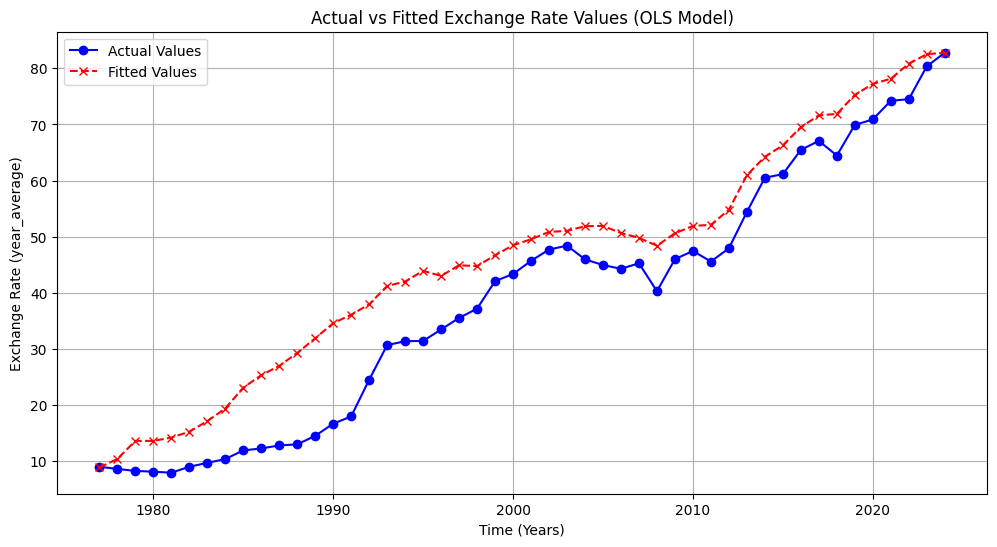

In [55]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(years, actual_values, label='Actual Values', color='blue', marker='o')
plt.plot(years, fitted_values, label='Fitted Values', color='red', linestyle='--', marker='x')

# Adding labels and title
plt.title('Actual vs Fitted Exchange Rate Values (OLS Model)')
plt.xlabel('Time (Years)')
plt.ylabel('Exchange Rate (year_average)')
plt.legend()
plt.grid(True)
plt.show()

#### Residual Analysis

RMSE: 8.556956564134163


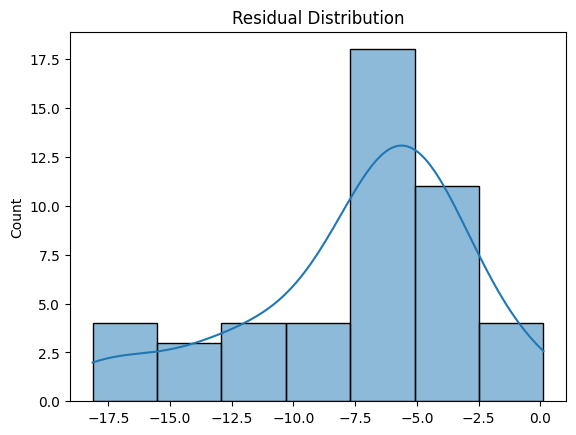

Shapiro-Wilk Test p-value: 0.0032035738647326543


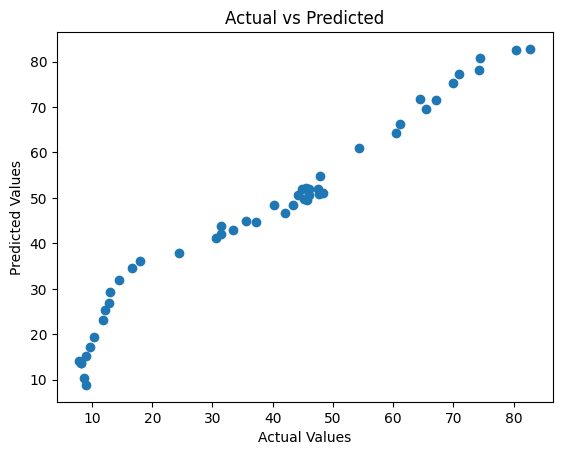

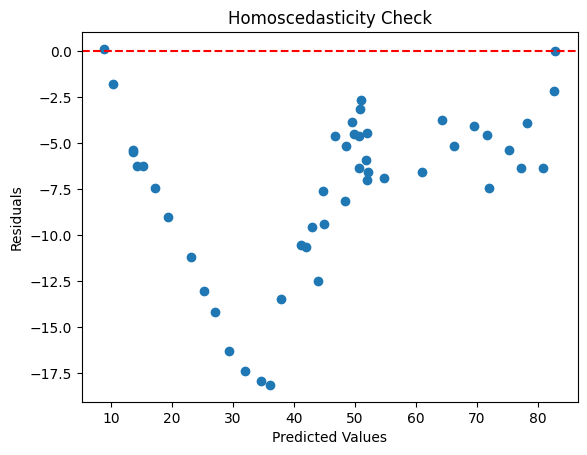

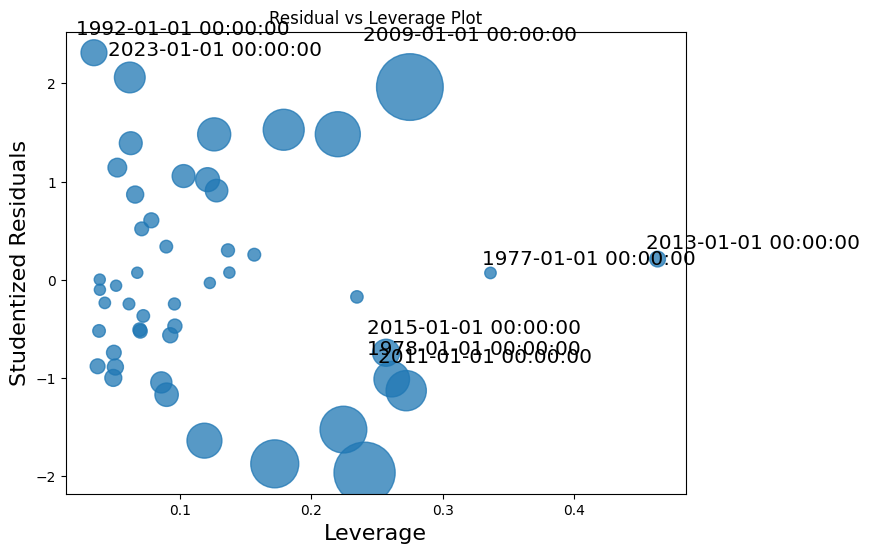

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

# Model Evaluation
print("RMSE:", np.sqrt(mean_squared_error(actual_values, fitted_values)))

# Check residuals
residuals = actual_values - fitted_values
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# Normality test (Shapiro-Wilk Test)
shapiro_test = shapiro(residuals)
print("Shapiro-Wilk Test p-value:", shapiro_test.pvalue)

# Plot actual vs predicted
plt.scatter(actual_values, fitted_values)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

# Check for homoscedasticity
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")
plt.show()

# Residual vs Leverage Plot
fig, ax = plt.subplots(figsize=(8,6))
sm.graphics.influence_plot(ecm_model, ax=ax, criterion="cooks")
plt.title("Residual vs Leverage Plot")
plt.show()

Thus in the above model we see that resisudal dont pass the diagnostics.